## **Course:** DSC670 - Advanced Uses of Generative AI
## **Name:** Tim Hollis
## **Assignment:** Assessment 7.2
## **Date:** July 25, 2026

---

The setup cell below installs the four libraries the article depends on, imports everything the
notebook will use, fixes the random seeds, defines the plotting palette, and pulls the quote
dataset down from Hugging Face. Every hyperparameter MacFarquhar (2024) specifies is lifted into a
named constant here rather than buried in the cell where it gets used. That is partly a style
preference, but it also makes the replication auditable: anyone reviewing this notebook can compare
the constants block against the article's code listing in one pass instead of hunting through six
cells.

The runtime for this notebook is a Google Colab T4 GPU. The article was written on a GTX 1080 Ti
with 11 GB of VRAM, and the T4's 16 GB is comfortably above that, so the training run should
reproduce without any memory tuning.

---

**Reference**

MacFarquhar, M. (2024, March 19). *Sculpting language: GPT-2 fine-tuning with LoRa*. Dev Genius. https://blog.devgenius.io/sculpting-language-gpt-2-fine-tuning-with-lora-1caf3bfbc3c6

Abirate. (2022). *English quotes* [Data set]. Hugging Face. https://huggingface.co/datasets/Abirate/english_quotes

Hu, E. J., Shen, Y., Wallis, P., Allen-Zhu, Z., Li, Y., Wang, S., Wang, L., & Chen, W. (2021). *LoRA: Low-rank adaptation of large language models* (arXiv:2106.09685). arXiv. https://arxiv.org/abs/2106.09685

Radford, A., Wu, J., Child, R., Luan, D., Amodei, D., & Sutskever, I. (2019). *Language models are unsupervised multitask learners*. OpenAI.

---

### **Initial Setup**

In [39]:
!pip install -q transformers datasets peft accelerate
!pip install -q ftfy


#Libraries
import ast
import os
import warnings
import ftfy
import matplotlib.pyplot as plt
import numpy as np
import torch
import transformers
from datasets import load_dataset
from peft import LoraConfig, get_peft_model
from transformers import AutoModelForCausalLM, AutoTokenizer

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Colorblind-safe palette
ROYAL_BLUE = '#4169E1'
PURPLE = '#4B0082'
FOREST_GREEN = '#228B22'
AMBER = '#E69F00'
LIGHT_GRAY = '#D3D3D3'
DARK_GRAY = '#4D4D4D'

# Visualization formatting
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Model and data identifiers from the article
MODEL_NAME = 'gpt2'
DATASET_NAME = 'Abirate/english_quotes'
SEPARATOR = ' ->: '

# LoRA hyperparameters from the article
LORA_RANK = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05

# Training hyperparameters from the article
LEARNING_RATE = 0.0002
BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 4
WARMUP_STEPS = 100
MAX_STEPS = 500

# Additions of mine, explained in the sections where they are used
MAX_LENGTH = 128
HOLDOUT_FRACTION = 0.1
PERPLEXITY_SAMPLE = 200
GENERATION_SAMPLE = 40

TEST_PROMPT = '“Life is like a box of chocolates, you never know what you are gonna get”' + SEPARATOR
MY_PROMPT = '“We are more alike, my friends, than we are unalike.”' + SEPARATOR

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'🖥️  Runtime device: {DEVICE}')
if torch.cuda.is_available():
    print(f'⚡ GPU online: {torch.cuda.get_device_name(0)}')
    print(f'🧠 VRAM available: {torch.cuda.get_device_properties(0).total_memory / 1024 ** 3:,.1f} GB')

raw_data = load_dataset(DATASET_NAME)
quote_count = len(raw_data['train'])
print(f'📚 Quote records loaded: {quote_count:,}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00
🖥️  Runtime device: cuda
⚡ GPU online: Tesla T4
🧠 VRAM available: 14.6 GB
📚 Quote records loaded: 2,508


<br><br><br><br>

## **Overview**

MacFarquhar (2024) builds his walkthrough around a single idea: a task can be reshaped into the one
operation a GPT model already performs, which is predicting the next token. The worked example takes
GPT-2, a model pretrained on generic web text, and adapts it to tag quotes with topic labels.
Nothing in GPT-2's architecture represents a tag. The task is carried entirely by the shape of the
training data.

The second idea is LoRA. Fully fine-tuning GPT-2 means updating all of the weights in the
checkpoint, which is slow and produces a full-size model file for every task trained. Hu et al.
(2021) observed that the weight update learned during fine-tuning tends to be low-rank, meaning it
can be approximated by the product of two much smaller matrices. LoRA freezes the pretrained weights
and trains only that low-rank pair, on the reasoning that adapting to one narrow task should not
require as many parameters as learning a language.

This notebook rebuilds the article's pipeline end to end and then adds a quantitative evaluation
section. Where my implementation differs from the code in the article, I note the difference and the
reasoning behind it.

**Roadmap**

1. Restructure the quote data into completion-shaped sequences
2. Load GPT-2, freeze it, and attach the LoRA adapter
3. Establish a baseline by generating from the unadapted model
4. Tokenize and configure the data collator
5. Train the adapter
6. Save the weights
7. Run inference on the article's test prompt and one of my own
8. Evaluate quantitatively

### **1. Restructuring the Data**

This step carries the whole approach, and it is three lines of code.

The dataset ships with a `quote` column and a `tags` column, where tags is a Python list of strings.
These are collapsed into a single `prediction` column formatted as `{quote} ->: {tags}`. The ` ->: `
string does the work. It is an arbitrary sentinel with no special meaning to GPT-2's tokenizer, but
because it appears in the same structural position in every training example, the model learns to
associate it with a change in behavior: the quote ends here and the tag list begins.

Two properties of this format are worth noting up front, because both reappear in the evaluation.

The tags are converted with `str()`, so the training target is a Python list representation
including square brackets, single quotes, and comma spacing. The model therefore has to learn that
punctuation alongside the tag vocabulary itself.

There is also no end-of-sequence marker in the sequences. Nothing in the training data indicates
where the tag list stops, so at generation time the model has no learned signal telling it to
terminate.

I applied `ftfy.fix_text` to each quote before formatting. Inspecting the raw records showed
mojibake in the source corpus, where sequences such as `â€™` and `â€”` appear in place of an
apostrophe and an em dash. Because those artifacts consume several tokens each and would be learned
as ordinary text, repairing the encoding first keeps the training targets clean. I also added a ten
percent held-out split so that section 8 can measure performance on records the adapter never saw,
and a leakage check confirming my own test quote appears in neither split.

In [40]:
def merge_columns(entry):
    """Collapse the quote and tags columns into one completion-shaped sequence."""
    clean_quote = ftfy.fix_text(entry['quote'])
    entry['prediction'] = clean_quote + SEPARATOR + str(entry['tags'])
    return entry


structured = raw_data['train'].map(merge_columns)

# Held-out split for the evaluation in section 8
split = structured.train_test_split(test_size=HOLDOUT_FRACTION, seed=SEED)
train_data = split['train']
holdout_data = split['test']

print(f'🧩 Training records: {len(train_data):,}')
print(f'🧪 Held-out records: {len(holdout_data):,}')
print()
print('📝 Formatted training sequences:')
for record in train_data['prediction'][:3]:
    print(f'   {record[:170]}')

# Leakage check for the second test quote
probe = MY_PROMPT.split(SEPARATOR)[0].strip('“”" ').lower()[:40]
train_hits = [record for record in train_data['quote'] if probe in record.lower()]
holdout_hits = [record for record in holdout_data['quote'] if probe in record.lower()]

print()
print(f'🔍 Probe text: {probe}')
print(f'⚠️  Appearances in the training split: {len(train_hits):,}')
print(f'🧪 Appearances in the held-out split: {len(holdout_hits):,}')

Map:   0%|          | 0/2508 [00:00<?, ? examples/s]

🧩 Training records: 2,257
🧪 Held-out records: 251

📝 Formatted training sequences:
   "If I got rid of my demons, I'd lose my angels." ->: ['angels', 'demons']
   "As usual, there is a great woman behind every idiot." ->: ['beatles', 'men', 'women']
   "The most important thing is to enjoy your life—to be happy—it's all that matters." ->: ['happiness', 'life']

🔍 Probe text: we are more alike, my friends, than we a
⚠️  Appearances in the training split: 0
🧪 Appearances in the held-out split: 0


### **2. Loading GPT-2 and Attaching the Adapter**

GPT-2 and its tokenizer are loaded from the `gpt2` checkpoint, and the padding token is pointed at
the end-of-sequence token because GPT-2 ships without a dedicated pad token. Every parameter tensor
is then set to `requires_grad = False`. This freeze loop is redundant in the sense that
`get_peft_model` freezes the base weights when it wraps the model, but keeping it makes the central
mechanism visible in the code rather than leaving it implicit in a library call.

Rank is the parameter that determines how much is trained. GPT-2's attention block uses a fused
query-key-value projection called `c_attn`, which is a 768 by 2,304 matrix, or 1,769,472 weights per
layer. At rank 16, LoRA represents the update to that matrix as a 768 by 16 matrix multiplied by a
16 by 2,304 matrix, which is 49,152 weights. Across the twelve layers this comes to the 589,824
trainable parameters reported below, against 125,029,632 total. The alpha value of 32 divided by the
rank of 16 gives a scaling factor of two applied to the adapter's contribution, which adjusts how
strongly the adaptation pulls against the frozen weights without changing the rank.

I named `target_modules` explicitly rather than relying on PEFT's internal default mapping. The
default resolves to `c_attn` and the behavior is the same, but stating it pins the configuration so
that a future library version cannot change which modules are adapted without the change being
visible here.

In [42]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE)

# Freeze the pretrained weights, following the article
for param in base_model.parameters():
    param.requires_grad = False

lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=['c_attn'],
    bias='none',
    task_type='CAUSAL_LM'
)

model = get_peft_model(base_model, lora_config).to(DEVICE)


def report_trainable_parameters(peft_model):
    trainable = sum(p.numel() for p in peft_model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in peft_model.parameters())
    print(f'🔓 Trainable parameters: {trainable:,}')
    print(f'🔒 Total parameters: {total:,}')
    print(f'📉 Proportion being trained: {100 * trainable / total:.4f}%')
    print(f'🎯 Reduction factor: {total / trainable:,.0f}x fewer weights to update')


report_trainable_parameters(model)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

🔓 Trainable parameters: 589,824
🔒 Total parameters: 125,029,632
📉 Proportion being trained: 0.4717%
🎯 Reduction factor: 212x fewer weights to update


### **3. Establishing the Baseline**

Before any training, the test prompt is run through the unadapted model. A before-and-after pair is
the minimum evidence needed to attribute a change in output to the fine-tuning rather than to the
prompt itself, so this generation serves as the control for section 7.

Base GPT-2 has no reason to treat ` ->: ` as anything other than ordinary punctuation. It sees a
quoted sentence followed by symbols and continues the text as text. In my run it produced an
emoticon followed by a partial echo of the quote, which is a plausible continuation of a string that
looks like forum or chat text. The model is not failing at tagging so much as answering a different
question than the one being asked.

Rather than instantiating a second copy of GPT-2, I used PEFT's `disable_adapter` context manager,
which routes the forward pass around the LoRA layers. This uses less memory and guarantees the
baseline and the adapted model are identical in every respect except the adapter.

I set `do_sample=False` for greedy decoding so that the comparison is deterministic. With sampling
enabled, a difference between the baseline and the adapted output could come from the random draw
rather than from the adapter, and greedy decoding removes that ambiguity.

In [43]:
def generate_tags(active_model, prompt, max_new_tokens=25):
    """Generate a tag list for one prompt and return only the new tokens.

    Decoding is greedy so that any difference between the baseline and tuned
    output is attributable to the adapter rather than to sampling noise. Slicing
    off the prompt by token count avoids the whitespace drift that string
    slicing on the decoded text can introduce.
    """
    active_model.eval()
    batch = tokenizer(prompt, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        output_tokens = active_model.generate(
            **batch,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    prompt_length = batch['input_ids'].shape[1]
    generated = output_tokens[0][prompt_length:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()


with model.disable_adapter():
    baseline_output = generate_tags(model, TEST_PROMPT)

print('🎬 Baseline generation, adapter disabled')
print(f'   Prompt: {TEST_PROMPT}')
print(f'   Output: {baseline_output}')

🎬 Baseline generation, adapter disabled
   Prompt: “Life is like a box of chocolates, you never know what you are gonna get” ->: 
   Output: ༼ つ ◕_◕ ༽つ Life is like a box of chocolates, you


### **4. Tokenization and the Data Collator**

The `prediction` column is tokenized in a batched map, and
`DataCollatorForLanguageModeling(tokenizer, mlm=False)` is handed to the trainer. That collator is
the most consequential line in the training setup and the easiest one to read past, so it is worth
being precise about what it does.

It performs two jobs. It pads each batch to the length of the longest sequence in that batch rather
than to a fixed global width, which saves computation on short examples. And with `mlm=False` it
constructs the labels for causal language modeling by copying the input ids and then setting every
padding position to negative one hundred, the sentinel value PyTorch's cross entropy loss uses to
skip a position entirely.

That second behavior is what makes the training correct. If sequences were padded to a fixed width
and the labels copied without masking, the loss would be computed over the padding as well, and on
short sequences the padding can be most of a training example. The printed counts below confirm the
masking is working: of 124 label positions in the sample batch, 13 are excluded and 111 are trained
on.

I set truncation at 128 tokens so that a single unusually long quote cannot set the padded width for
every example batched alongside it. In this dataset the quotes are short enough that it rarely
matters, but it is an inexpensive guard against a memory spike.

In [44]:
def tokenize_batch(samples):
    """Encode the prediction column, capping sequences at MAX_LENGTH tokens.

    Padding is deliberately left to the collator so each batch pads to its own
    longest sequence rather than to a fixed global width. Truncation guards
    against one long quote setting the batch width for everything alongside it.
    """
    return tokenizer(samples['prediction'], truncation=True, max_length=MAX_LENGTH)

tokenized_train = train_data.map(
    tokenize_batch,
    batched=True,
    remove_columns=train_data.column_names
)
tokenized_holdout = holdout_data.map(
    tokenize_batch,
    batched=True,
    remove_columns=holdout_data.column_names
)

collator = transformers.DataCollatorForLanguageModeling(tokenizer, mlm=False)

# Inspect one collated batch to confirm the padding mask behaves as expected
sample_batch = collator([tokenized_train[index] for index in range(BATCH_SIZE)])
label_shape = tuple(sample_batch['labels'].shape)
total_positions = int(sample_batch['labels'].numel())
ignored_positions = int((sample_batch['labels'] == -100).sum())

print(f'🔢 Batch tensor shape: {label_shape}')
print(f'📏 Total label positions: {total_positions:,}')
print(f'🙈 Positions excluded from the loss: {ignored_positions:,}')
print(f'✅ Positions actually trained on: {total_positions - ignored_positions:,}')

Map:   0%|          | 0/2257 [00:00<?, ? examples/s]

Map:   0%|          | 0/251 [00:00<?, ? examples/s]

🔢 Batch tensor shape: (4, 31)
📏 Total label positions: 124
🙈 Positions excluded from the loss: 13
✅ Positions actually trained on: 111


### **5. Training the Adapter**

The configuration uses a per-device batch size of 4 with 4 gradient accumulation steps, giving an
effective batch of 16. That pairing is a memory accommodation rather than a modeling decision:
gradients from four consecutive micro-batches are summed before the optimizer steps, producing the
same update as a batch of 16 while only holding four examples of activations in VRAM at a time. On
an 11 GB card that distinction matters. On a T4 it is not strictly required, but I kept it because
changing it would alter the effective learning dynamics and the run would no longer match the
article's configuration.

Training runs for 500 steps with 100 warmup steps. At a learning rate of 0.0002 against a freshly
initialized adapter, a warmup period is reasonable, since the B matrix starts at zero and the
adapter contributes nothing to the forward pass until it begins to move. Capping at `max_steps`
rather than epochs means the run is bounded by compute rather than by convergence, so the model is
not necessarily finished learning when training stops. With 2,257 training records and an effective
batch of 16, 500 steps works out to roughly three and a half passes over the data.

Setting `model.config.use_cache = False` disables the key-value cache used to accelerate
autoregressive generation. During training the cache serves no purpose, because the full sequence is
processed in a single forward pass, and leaving it enabled consumes memory unnecessarily. I turn it
back on afterward so that the generation in later sections is not slowed down, which is a step a
single notebook needs but a two-script structure does not.

In [ ]:
# Training Parameters
training_args = transformers.TrainingArguments(
    output_dir='outputs',
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    warmup_steps=WARMUP_STEPS,
    max_steps=MAX_STEPS,
    learning_rate=LEARNING_RATE,
    logging_steps=10,
    report_to='none',
    seed=SEED
)

trainer = transformers.Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    data_collator=collator
)

model.config.use_cache = False
train_result = trainer.train()
model.config.use_cache = True

In [50]:
print()
print(f'🏁 Optimizer steps completed: {train_result.global_step:,}')
print(f'📊 Final training loss: {train_result.training_loss:.4f}')
runtime_seconds = train_result.metrics['train_runtime']
print(f'⏱️  Wall clock runtime: {runtime_seconds:,.1f} seconds')


🏁 Optimizer steps completed: 500
📊 Final training loss: 3.1240
⏱️  Wall clock runtime: 153.5 seconds


### **6. Saving the Weights**

Two save paths are worth distinguishing here, so I ran both.

`torch.save(model.state_dict(), 'lora.pt')` serializes every tensor held by the wrapped object,
which includes the frozen GPT-2 weights along with the adapter weights. The resulting file is
roughly the size of the base model. Reloading it also requires reconstructing the identical PEFT
wrapper first, since `load_state_dict` matches on tensor names.

`save_pretrained` writes only the trainable adapter tensors plus a small configuration file
describing how to reattach them to a base model. This is the form that supports the deployment
pattern Hu et al. (2021) describe, where one shared base model is served and small task-specific
adapters are swapped in as needed.

The measured difference is 477.0 MB against 2.26 MB, a factor of 211, which matches the ratio of
total parameters to trainable parameters reported in section 2.

In [46]:
# Full state dictionary
torch.save(model.state_dict(), 'lora.pt')
full_state_mb = os.path.getsize('lora.pt') / (1024 ** 2)

# Adapter weights only
model.save_pretrained('lora_adapter')
adapter_mb = sum(
    os.path.getsize(os.path.join('lora_adapter', filename))
    for filename in os.listdir('lora_adapter')
) / (1024 ** 2)

print(f'💾 Full state dict, the article method: {full_state_mb:,.1f} MB')
print(f'💾 Adapter only, save_pretrained: {adapter_mb:,.2f} MB')
print(f'📦 Storage reduction: {full_state_mb / adapter_mb:,.0f}x smaller')

💾 Full state dict, the article method: 477.0 MB
💾 Adapter only, save_pretrained: 2.26 MB
📦 Storage reduction: 211x smaller


<br><br><br><br><br><br><br><br><br><br>

### **7. Inference**

The article separates inference into its own script, which rebuilds GPT-2, rebuilds the identical
LoRA configuration, wraps the model, and loads the saved weights into it. In a notebook the trained
object is already in memory, so I generate from it directly.

I ran two prompts. The first is the article's own test case, which lets me compare my result against
the published one. The second is a Maya Angelou quote that the leakage check in section 1 confirmed
appears in neither the training nor the held-out split, so it tests whether the adapter generalizes
beyond the single example the article demonstrates.

In [47]:
tuned_output = generate_tags(model, TEST_PROMPT)

print('🎯 Fine-tuned generation, adapter active')
print(f'   Prompt: {TEST_PROMPT}')
print(f'   Output: {tuned_output}')
print()
print('🔁 Side-by-side comparison')
print(f'   Before: {baseline_output}')
print(f'   After:  {tuned_output}')

with model.disable_adapter():
    my_baseline = generate_tags(model, MY_PROMPT)

my_tuned = generate_tags(model, MY_PROMPT)

print()
print('🧪 Second test case, not from the article')
print(f'   Prompt: {MY_PROMPT}')
print(f'   Before: {my_baseline}')
print(f'   After:  {my_tuned}')

🎯 Fine-tuned generation, adapter active
   Prompt: “Life is like a box of chocolates, you never know what you are gonna get” ->: 
   Output: iced-candy, 'life', 'life', 'life-inspirational', 'life-inspirational-

🔁 Side-by-side comparison
   Before: ༼ つ ◕_◕ ༽つ Life is like a box of chocolates, you
   After:  iced-candy, 'life', 'life', 'life-inspirational', 'life-inspirational-

🧪 Second test case, not from the article
   Prompt: “We are more alike, my friends, than we are unalike.” ->: 
   Before: ㅠㅠㅠㅠㅠㅠㅠㅠ�
   After:  vernacular:friendship,humor,humor-of-the-people,humor-of-the-


<br><br><br><br><br><br><br><br>

### **8. Evaluation**

This section measures whether the fine-tuning taught the model the task, or whether it changed the
output in a way that looks different without being better. Three measurements address that from
different angles.

**Training loss trajectory** indicates whether the adapter was still improving when the step budget
ran out. Because training is capped at 500 steps rather than run to convergence, a curve that is
still descending at the end would mean the run was bounded by compute rather than by the model
having finished learning.

**Held-out perplexity** is the quantitative counterpart to the before-and-after generation.
Perplexity is the exponentiated average cross entropy, and it measures roughly how surprised a model
is by text it has not seen. Computing it on held-out records with the adapter disabled and then
enabled isolates what the adapter contributes. A large gap indicates the adapter learned something
that transfers, while a flat result would suggest it only fit the training split.

**Tag format adherence** is a task-specific check. I generate tags for 40 held-out quotes and test
whether the output parses as a non-empty Python list using `ast.literal_eval`. This measures whether
the model reproduces the output contract that the ` ->: ` sentinel and the bracketed target format
are meant to teach. It is a check on structure, not on whether the tags chosen are appropriate.

In [48]:
def holdout_perplexity(active_model, dataset, sample_size=PERPLEXITY_SAMPLE):
    """Exponentiated mean cross entropy over held-out records.

    Run once with the adapter disabled and once with it active to isolate what
    the adapter contributes. A large gap indicates the model generalized, while
    a flat result would suggest it only memorized the training split.
    """
    active_model.eval()
    losses = []
    subset = dataset.select(range(min(sample_size, len(dataset))))
    for index in range(len(subset)):
        batch = collator([subset[index]])
        batch = {key: value.to(DEVICE) for key, value in batch.items()}
        with torch.no_grad():
            outputs = active_model(**batch)
        losses.append(outputs.loss.item())
    return float(np.exp(np.mean(losses)))


def tag_parse_rate(active_model, dataset, sample_size=GENERATION_SAMPLE):
    """Share of generations that parse as a non-empty Python list.

    Measures whether the model learned the output contract the ' ->: ' sentinel
    is meant to teach. This is a format check, not a quality check, and says
    nothing about whether the tags are semantically appropriate.
    """
    successes = 0
    for index in range(sample_size):
        prompt = dataset[index]['quote'] + SEPARATOR
        continuation = generate_tags(active_model, prompt)
        if ']' not in continuation:
            continue
        candidate = continuation.split(']')[0] + ']'
        try:
            parsed = ast.literal_eval(candidate)
        except (ValueError, SyntaxError):
            continue
        if isinstance(parsed, list) and len(parsed) > 0:
            successes += 1
    return successes / sample_size


with model.disable_adapter():
    base_perplexity = holdout_perplexity(model, tokenized_holdout)
    base_parse_rate = tag_parse_rate(model, holdout_data)

tuned_perplexity = holdout_perplexity(model, tokenized_holdout)
tuned_parse_rate = tag_parse_rate(model, holdout_data)

print(f'📈 Held-out perplexity, base GPT-2: {base_perplexity:,.2f}')
print(f'📉 Held-out perplexity, LoRA tuned: {tuned_perplexity:,.2f}')
print(f'✨ Perplexity improvement: {100 * (1 - tuned_perplexity / base_perplexity):,.1f}%')
print()
print(f'🏷️  Valid tag list rate, base GPT-2: {100 * base_parse_rate:,.1f}%')
print(f'🏷️  Valid tag list rate, LoRA tuned: {100 * tuned_parse_rate:,.1f}%')

📈 Held-out perplexity, base GPT-2: 59.24
📉 Held-out perplexity, LoRA tuned: 15.82
✨ Perplexity improvement: 73.3%

🏷️  Valid tag list rate, base GPT-2: 0.0%
🏷️  Valid tag list rate, LoRA tuned: 0.0%


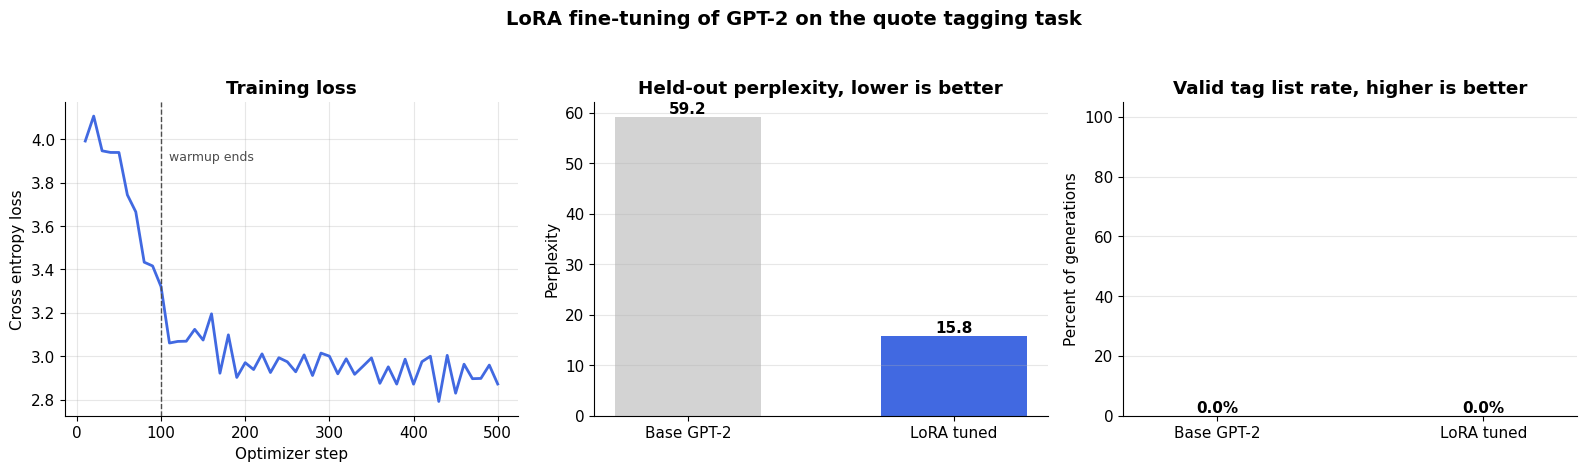

In [49]:
log_history = trainer.state.log_history
logged_steps = [entry['step'] for entry in log_history if 'loss' in entry]
logged_losses = [entry['loss'] for entry in log_history if 'loss' in entry]

figure, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(logged_steps, logged_losses, color=ROYAL_BLUE, linewidth=2)
axes[0].axvline(WARMUP_STEPS, color=DARK_GRAY, linestyle='--', linewidth=1)
axes[0].text(WARMUP_STEPS + 10, max(logged_losses) * 0.95, 'warmup ends', fontsize=9, color=DARK_GRAY)
axes[0].set_title('Training loss', fontweight='bold')
axes[0].set_xlabel('Optimizer step')
axes[0].set_ylabel('Cross entropy loss')

perplexity_labels = ['Base GPT-2', 'LoRA tuned']
perplexity_values = [base_perplexity, tuned_perplexity]
bars = axes[1].bar(perplexity_labels, perplexity_values, color=[LIGHT_GRAY, ROYAL_BLUE], width=0.55)
for bar, value in zip(bars, perplexity_values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f'{value:,.1f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )
axes[1].set_title('Held-out perplexity, lower is better', fontweight='bold')
axes[1].set_ylabel('Perplexity')
axes[1].grid(axis='x', alpha=0)

parse_values = [100 * base_parse_rate, 100 * tuned_parse_rate]
bars = axes[2].bar(perplexity_labels, parse_values, color=[LIGHT_GRAY, FOREST_GREEN], width=0.55)
for bar, value in zip(bars, parse_values):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f'{value:,.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )
axes[2].set_ylim(0, 105)
axes[2].set_title('Valid tag list rate, higher is better', fontweight='bold')
axes[2].set_ylabel('Percent of generations')
axes[2].grid(axis='x', alpha=0)

plt.suptitle(
    'LoRA fine-tuning of GPT-2 on the quote tagging task',
    fontsize=14,
    fontweight='bold',
    y=1.04
)
plt.tight_layout()
plt.show()

### **Interpreting the Results**

The three measurements do not agree with each other, and the disagreement is the most informative
part of this exercise.

**Perplexity improved substantially.** On held-out records the unadapted model scores 59.24 and the
adapted model scores 15.82, a reduction of 73.3 percent. Because these records were excluded from
training and the only difference between the two measurements is whether the adapter is active, this
is evidence that the adapter learned something that transfers rather than memorizing the training
split. Fewer than half a percent of the model's parameters were trainable, so this is the clearest
support in the notebook for the efficiency argument in Hu et al. (2021).

**Format adherence did not improve.** Both the unadapted and the adapted model score 0.0 percent,
and the reason is visible in the generations printed in section 7. The adapted model produces
recognizable tag content, including terms such as `life`, `life-inspirational`, `friendship`, and
`humor`, which are plausible topic labels and are clearly drawn from the tag vocabulary rather than
from ordinary prose. What it does not produce is a closed bracket. The output runs to the 25-token
limit and stops mid-word, in one case repeating `life-inspirational` and extending it into
`life-inspirational-`. Because there is no closing bracket in the string, `ast.literal_eval` has
nothing well-formed to parse and the check records a failure on every attempt.

I read this as tracing back to the two properties of the data format noted in section 1. Without a
terminator in the training sequences, the model has no learned signal for when a tag list is
complete, so it continues generating and drifts into repetition. And because the target format
requires balanced brackets, a generation that does not terminate cleanly fails a structural check
even when its content is substantively correct. The metric is measuring exactly what it was
specified to measure, which is why the result is worth reporting rather than adjusting.

<br><br><br>

**Taken together**, the adapted model learned the tag vocabulary and the association between a quote
and its topics, which is the substance of the task, but it did not learn to produce the serialized
format cleanly within the token budget. The perplexity result and the format result are not in
conflict once that distinction is drawn. Perplexity scores the probability the model assigns to
correct continuations, which improves when the vocabulary and associations are learned. The format
check scores a stricter property that also depends on termination.

The training loss curve is consistent with this. Loss was still descending at step 500, finishing at
3.1240, which indicates the run ended because the step budget was reached and not because the model
had converged.

<br><br><br>

### **Summary and Reflection**

Rebuilding this pipeline changed how I think about what fine-tuning actually does. The architecture
never changes. GPT-2 performs next-token prediction before training and next-token prediction after
it. What changes is that the data has been rewritten so that performing the task and predicting the
next token are the same operation. The ` ->: ` sentinel is a three-character intervention that
carries the entire task definition, and I do not think I would have registered that as a design
decision rather than a formatting detail without building it myself.

The efficiency side held up clearly. Fewer than 0.5 percent of the parameters were trainable, the
run finished on a free Colab T4 in 153.5 seconds, and the adapter serializes to 2.26 MB against
477.0 MB for the full state dictionary. For a narrow task layered on top of general language
competence, the low-rank approximation described by Hu et al. (2021) appears sufficient, and
updating 125 million parameters to learn quote tagging would have been disproportionate to what was
being learned.

What I found most useful was where the measurements disagreed. Had I stopped at the qualitative
before-and-after comparison in section 7, I would have concluded the fine-tuning worked, because the
output changed from an emoticon to something that reads like a list of topic tags. Had I stopped at
perplexity, I would have concluded the same thing with a number attached. It was the format check
returning zero that made me look closely at what the model was actually emitting and notice that it
never terminates. That is a limitation I would not have found without a metric that could fail.

If I extended this, three things would come first. I would add a terminator to the training
sequences so the model has a learned stopping signal, though this interacts awkwardly with LoRA
because the embedding matrix is frozen, so a registered special token would need the embeddings
unfrozen or a within-vocabulary sentinel chosen instead. I would raise the generation budget past 25
tokens and check whether termination improves or the repetition simply continues, which would
distinguish a truncation problem from a degeneration problem. And I would add a semantic metric,
such as overlap between generated tags and the true tags for each held-out quote, since format
adherence and perplexity together still say nothing about whether the tags chosen are the right
ones.

The claim I am comfortable making from this notebook is a narrow one. LoRA adapted GPT-2 to the
substance of the quote tagging task at very low cost, and the held-out perplexity supports that. The
serialized output format was not learned reliably within the configuration used here, and a
demonstration that a model can be adapted cheaply is not the same as a demonstration that the
adapted model is ready to be used.